<a href="https://colab.research.google.com/github/piaseckazaneta/Python/blob/main/Zaneta_Piasecka_Mini_projekt_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. WSTĘP

Cel mini-projektu: Integracja rozproszonych danych relacyjnych NOAA (National Oceanic and Atmospheric Administration) i stworzenie czystego, ujednoliconego zbioru danych (tzw. Master Dataset) o ekstremalnych zjawiskach pogodowych, gotowego do analizy statystycznej i przestrzennej (GIS).

Cel głównego projektu: Odpowiedź na pytanie: "O ile rosną straty finansowe zjawiska w zależności od jego skali fizycznej i czasu trwania?"

Projekt składa się z 2 głównych etapów:
1. Eksploracyjna analiza danych. Podczas EDA zostanie podjęta decyzja, dla którego zjawiska będzie budowany model. Do modelowania zostanie wybrane zjawisko, które generuje największe straty finansowe i dla którego są dostępne w tabeli dodatkowe cechy np. wielkość, skala itp.
2. Budowa modelu regresji liniowej służącego predykcji strat finansowych.

Źródło danych: NOAA.


## 1. IMPORT BIBLIOTEK

In [1]:
import pandas as pd

from google.colab import drive

drive.mount("/content/drive")



Mounted at /content/drive


## 2. WCZYTANIE DANYCH

Dane pobierane są z dysku google, przez co nie ma potrzeby wczytywania ich przy każdym uruchomieniu kodu.



In [2]:
# Ścieżki do dysku google
storm_events_details = "/content/drive/MyDrive/Projekt_Python_2026/StormEvents_details_2025.csv"
storm_events_locations = "/content/drive/MyDrive/Projekt_Python_2026/StormEvents_locations_2025.csv"
storm_events_fatalities = "/content/drive/MyDrive/Projekt_Python_2026/StormEvents_fatalities_2025.csv"

# Wczytanie danych
df_details = pd.read_csv(storm_events_details)
df_locations = pd.read_csv(storm_events_locations)
df_fatalities = pd.read_csv(storm_events_fatalities)


## 3. EKSPLORACYJNA ANALIZA DANYCH

### 3.1. Kontrola struktury danych

In [3]:
pd.set_option('display.max_columns', None)

# Sprawdzam 5 pierwszych wierszy tabeli
df_details.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202503,31,1104,202503,31,1106,201366,1252415,GEORGIA,13,2025,March,Thunderstorm Wind,C,45,CARROLL,FFC,31-MAR-25 11:04:00,EST-5,31-MAR-25 11:06:00,0,0,0,0,1.00K,NaN,Emergency Manager,52.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.22,W,TYUS,2.22,W,TYUS,33.4757,-85.238,33.4757,-85.238,A cold-front initiated a line of thunderstorms...,Tree down at the intersection of highway 5 and...,CSV
1,202503,30,1552,202503,30,1555,200337,1241136,MICHIGAN,26,2025,March,Tornado,C,27,CASS,IWX,30-MAR-25 15:52:00,EST-5,30-MAR-25 15:55:00,0,0,0,0,100.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,2.59,100.0,NaN,NaN,NaN,NaN,1.24,SW,EDWARDSBURG,1.47,NNE,EDWARDSBURG,41.7900,-86.100,41.8200,-86.070,A cold front pushed into the area during the a...,A brief EF-1 tornado was confirmed in Edwardsb...,CSV
2,202501,5,1800,202501,6,2227,197733,1222851,VIRGINIA,51,2025,January,Winter Storm,Z,56,SPOTSYLVANIA,LWX,05-JAN-25 18:00:00,EST-5,06-JAN-25 22:27:00,0,0,0,0,NaN,NaN,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure tracked across souther...,NaN,CSV
3,202501,3,1300,202501,3,1900,197761,1223112,MARYLAND,24,2025,January,Winter Weather,Z,506,CENTRAL AND SOUTHEAST HOWARD,LWX,03-JAN-25 13:00:00,EST-5,03-JAN-25 19:00:00,0,0,0,0,NaN,NaN,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV
4,202501,3,1300,202501,3,1900,197761,1223113,MARYLAND,24,2025,January,Winter Weather,Z,504,CENTRAL AND SOUTHEAST MONTGOMERY,LWX,03-JAN-25 13:00:00,EST-5,03-JAN-25 19:00:00,0,0,0,0,NaN,NaN,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV


In [4]:
# Sprawdzam 5 pierwszych wierszy tabeli
df_fatalities.head()

,FAT_YEARMONTH,FAT_DAY,FAT_TIME,FATALITY_ID,EVENT_ID,FATALITY_TYPE,FATALITY_DATE,FATALITY_AGE,FATALITY_SEX,FATALITY_LOCATION
0,202512,4,0,60389,1296292,I,12/04/2025 00:00:00,40.0,M,Vehicle/Towed Trailer
1,202512,1,0,60391,1296789,I,12/01/2025 00:00:00,35.0,F,Boating
2,202512,3,0,60393,1297305,D,12/03/2025 00:00:00,32.0,M,In Water
3,202512,25,0,60553,1298352,I,12/25/2025 00:00:00,75.0,F,Vehicle/Towed Trailer
4,202512,26,0,60562,1298509,D,12/26/2025 00:00:00,44.0,M,In Water


**Komentarz:**

Biorąc pod uwagę główny cel projektu, tabela df_fatalities zawierająca informacje o ofiarach zdarzeń nie będzie potrzebna do dalszych analiz. Nie ma w niej danych, które są niezbędne do analiz finansowych.

In [5]:
# Sprawdzam 5 pierwszych wierszy tabeli
df_locations.head()

,YEARMONTH,EPISODE_ID,EVENT_ID,LOCATION_INDEX,RANGE,AZIMUTH,LOCATION,LATITUDE,LONGITUDE,LAT2,LON2
0,202508,204641,1287936,2,3.54,SSE,SINKING COVE,35.0015,-85.9601,3590,8557606
1,202508,203789,1269348,1,2.90,E,BLEASES XRDS,34.0440,-81.7699,342640,8146194
2,202508,203789,1269349,1,0.80,WSW,DOUGLAS,34.6637,-80.8118,3439822,8048708
3,202508,204597,1288676,4,1.45,WSW,HUNTSVILLE,34.7237,-86.6444,3443422,8638664
4,202508,204597,1288677,1,1.79,NW,FT PAYNE ISBELL ARPT,34.4900,-85.7400,3429400,8544400


**Komentarz**:

Tabele wyglądają na uporządkowane.
Poprawnie wyglądają formaty dat, skrótowe oznaczenia kierunków świata.

Nazwy kolumn pisane wielkimi literami - Należy je zamienić na małe litery.

Tabela df_locations również nie będzie potrzebna w dalszych analizach, gdyż informacje o lokalizacji zjawiska tj. długość i szerokość geograficzna znajdują się w tabeli df_details i są wystarczające jako zmienne objaśniające do modelu.

Zmiana nazw kolumn w df_details na małe litery

In [6]:
df_details.columns = df_details.columns.str.lower()

Sprawdzenie rozmiaru tabeli df_details, typów kolumn i brakujących wartości

In [7]:
# Sprawdzam rozmiar tabeli i typy kolumn
df_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72241 entries, 0 to 72240
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   begin_yearmonth     72241 non-null  int64  
 1   begin_day           72241 non-null  int64  
 2   begin_time          72241 non-null  int64  
 3   end_yearmonth       72241 non-null  int64  
 4   end_day             72241 non-null  int64  
 5   end_time            72241 non-null  int64  
 6   episode_id          72241 non-null  int64  
 7   event_id            72241 non-null  int64  
 8   state               72241 non-null  object 
 9   state_fips          72241 non-null  int64  
 10  year                72241 non-null  int64  
 11  month_name          72241 non-null  object 
 12  event_type          72241 non-null  object 
 13  cz_type             72241 non-null  object 
 14  cz_fips             72241 non-null  int64  
 15  cz_name             72241 non-null  object 
 16  wfo 

**Komentarz**:

Użycie .info() służyło sprawdzeniu typów danych i potencjalnych braków danych dzięki kolumnie Non-Null Count. Można odczytać też liczbę wierszy w tabeli.

Całkowita liczba wierszy: 72241.

Kolumny "begin_date_time" i "end_date_time" są w formacie object - do konwersji na datetime64. Jest to konieczne, aby obliczyć czas trwania zjawiska.

Wartości w kolumnie "begin_date_time" zawierają date i czas -> należy te informacje rozdzielić na osobne kolumny, aby móc później określić sezonowość (miesiąc) i porę dnia (godzina) poszczególnych zjawisk. Kolumny te będą stanowiły dodatkowe zmienne objaśniające do modelu.

Do modelu należy obliczyć czas trwania zjawiska. W tym celu należy utworzyć dodatkowo nową kolumnę 'duration_minutes', obliczając różnicę między 'begin_date_time' i 'end_date_time'.

Kwoty strat ("damage") dotyczące zniszczeń są w formacie object - do konwersji.

Skala tornada (tor_f_scale) jest w formacie object - do późniejszych obliczeń będzie potrzebny format liczbowy. Należy przeprowadzić standaryzację skali tornad, czyli oczyszczenie kolumny tor_f_scale (wyciągnięcie samej cyfry ze stringów typu "EF2").

Braki w danych:
ok. 20 tys. z 72 tys. brakujących wartości w kolumnie "damage_crops" - do sprawdzenia (powinno być 0, czy zdarzenie nie dotyczy zniszczeń upraw?)
ok. 70 tys. brakujących wartości dla skali, długości i szerokości tornad (tor_f_scale, tor_length, tor_width) - do sprawdzenia, prawdopodobnie brakujące wiersze są innymi zdarzeniami niż tornado.

Reszta interesujących kolumn ma poprawny format i kompletną liczbę wartości.

### 3.2. Sprawdzenie duplikatów

Sprawdzenie unikalności kolumny "event_id", na podstawie której możemy określić poziom agregacji tabeli df_details.

In [8]:
# Sprawdzam, czy kolumna "event_id" posiada unikalne wartości, używając sposobu na sprawdzenie liczby duplikatów
df_details["event_id"].duplicated().sum()

np.int64(0)

**Komentarz:**

Kolumna "event_id" nie ma duplikatów - wartości są unikalne, zatem można stwierdzić, że jeden wiersze tabeli odpowiada jednemu zdarzeniu pogodowemu, które miało miejsce w określonym czasie i określonym miejscu.

### 3.3. Sprawdzenie miar statystyki opisowej

In [9]:
# Sprawdzam miary statystyczne do ogólnego spojrzenia na dane, ewentualne wartości odstające
df_details.describe(include='all')

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source
count,72241.000000,72241.000000,72241.000000,72241.000000,72241.000000,72241.000000,72241.000000,7.224100e+04,72241,72241.000000,72241.0,72241,72241,72241,72241.000000,72241,72241,72241,72241,72241,72241.000000,72241.000000,72241.000000,72241.000000,55842,55095,72241,38971.000000,29741,7817,0.0,1591,1591.000000,1591.000000,282,282,282.000000,282,43917.000000,43917,43917,43917.000000,43917,43917,43917.000000,43917.000000,43917.000000,43917.000000,72241,61496,72241
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68,NaN,NaN,12,48,2,NaN,3405,123,37727,11,36501,NaN,NaN,NaN,NaN,260,58,42,NaN,4,6,NaN,7,NaN,NaN,48,28,NaN,192,NaN,16,16927,NaN,16,16971,NaN,NaN,NaN,NaN,8898,53486,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TEXAS,NaN,NaN,June,Thunderstorm Wind,C,NaN,JACKSON,OUN,01-NOV-25 00:00:00,CST-6,31-OCT-25 23:59:00,NaN,NaN,NaN,NaN,0.00K,0.00K,Public,NaN,EG,Heavy Rain,NaN,EF1,NaN,NaN,JAN,MS,NaN,WASHINGTON,NaN,N,FLORENCE,NaN,N,FLORENCE,NaN,NaN,NaN,NaN,A cluster of supercells developed during the l...,Maximum heat index of 105 degrees.,CSV
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5641,NaN,NaN,9936,21807,41531,NaN,659,2535,343,35400,334,NaN,NaN,NaN,NaN,41415,54616,12861,NaN,18458,7635,NaN,623,NaN,NaN,28,38,NaN,7,NaN,7024,48,NaN,6807,48,NaN,NaN,NaN,NaN,412,447,72241
mean,202505.620451,15.113038,1281.282139,202505.620451,16.530488,1449.093368,203223.827826,1.265526e+06,NaN,33.584488,2025.0,NaN,NaN,NaN,109.324331,NaN,NaN,NaN,NaN,NaN,0.014147,0.004277,0.008693,0.003613,NaN,NaN,NaN,40.499311,NaN,NaN,NaN,NaN,3.987203,243.283470,NaN,NaN,100.212766,NaN,2.376620,NaN,NaN,2.382360,NaN,NaN,37.430153,-90.057825,37.430663,-90.053952,NaN,NaN,NaN
std,2.992886,8.661094,659.785132,2.992886,8.681507,616.808726,3181.344483,2.307369e+04,NaN,19.114886,0.0,NaN,NaN,NaN,135.791440,NaN,NaN,NaN,NaN,NaN,0.770202,0.241112,0.330578,0.099282,NaN,NaN,NaN,23.091692,NaN,NaN,NaN,NaN,4.604264,333.863382,NaN,NaN,81.201372,NaN,4.408162,NaN,NaN,4.414841,NaN,NaN,5.205849,11.339800,5.206291,11.339300,NaN,NaN,NaN
min,202501.000000,1.000000,0.000000,202501.000000,1.000000,0.000000,197521.000000,1.221835e+06,NaN,1.000000,2025.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.250000,NaN,NaN,NaN,NaN,0.010000,1.000000,NaN,NaN,1.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,-14.338000,-170.833900,-14.338000,-170.832600,NaN,NaN,NaN
25%,202503.000000,8.000000,835.000000,202503.000000,9.000000,1100.000000,200491.000000,1.245845e+06,NaN,20.000000,2025.0,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,0.820000,50.000000,NaN,NaN,43.000000,NaN,0.690000,NaN,NaN,0.690000,NaN,NaN,34.328900,-97.150000,34.329800,-97.150000,NaN,NaN,NaN
50%,202505.000000,16.000000,1438.000000,202505.000000,17.000000,1600.000000,202803.000000,1.265417e+06,NaN,34.000000,2025.0,NaN,NaN,NaN,67.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,2.390000,100.000000,NaN,NaN,83.000000,NaN,1.380000,NaN,NaN,1.380000,NaN,NaN,37.700000,-88.714700,37.702800,-88.710000,NaN,NaN,NaN
75%,202507.000000,21.000000,1800.000000,202507.000000,24.000000,1900.000000,205750.000000,1.284940e+06,NaN,47.000000,2025.0,NaN,NaN,NaN,123.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,NaN,5.495000,300.000000,NaN,NaN,135.000000,NaN,2.690000,NaN,NaN,2.680000,NaN,NaN

In [10]:
df_details[df_details["event_type"] == "Tornado"].describe(include='all')

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1.591000e+03,1591,1591.000000,1591.0,1591,1591,1591,1591.000000,1591,1591,1591,1591,1591,1591.000000,1591.000000,1591.000000,1591.0,1296,1294,1591,0.0,0,0,0.0,1591,1591.000000,1591.000000,282,282,282.000000,282,1591.000000,1591,1591,1591.000000,1591,1591,1591.000000,1591.000000,1591.000000,1591.000000,1591,1591,1591
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,12,1,1,NaN,605,91,1536,4,1539,NaN,NaN,NaN,NaN,102,16,21,NaN,0,0,NaN,7,NaN,NaN,48,28,NaN,192,NaN,16,1386,NaN,16,1401,NaN,NaN,NaN,NaN,526,1552,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TEXAS,NaN,NaN,April,Tornado,C,NaN,WASHINGTON,MEG,20-APR-25 19:58:00,CST-6,16-MAY-25 18:06:00,NaN,NaN,NaN,NaN,0.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,NaN,NaN,JAN,MS,NaN,WASHINGTON,NaN,WSW,MERRITT RES,NaN,ENE,MERRITT RES,NaN,NaN,NaN,NaN,Isolated severe thunderstorms developed across...,An EF-2 tornado began along US Highway 49 nort...,CSV
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143,NaN,NaN,370,1591,1591,NaN,22,79,3,1206,3,NaN,NaN,NaN,NaN,620,1262,1257,NaN,NaN,NaN,NaN,623,NaN,NaN,28,38,NaN,7,NaN,132,8,NaN,146,8,NaN,NaN,NaN,NaN,32,4,1591
mean,202504.961659,15.301697,1500.607165,202504.961659,15.305468,1502.153991,202377.214331,1.261320e+06,NaN,28.007542,2025.0,NaN,NaN,NaN,97.940289,NaN,NaN,NaN,NaN,NaN,0.155877,0.005657,0.040226,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.987203,243.283470,NaN,NaN,100.212766,NaN,3.661898,NaN,NaN,3.704852,NaN,NaN,37.598206,-91.846931,37.622268,-91.792875,NaN,NaN,NaN
std,1.975425,8.380465,610.089002,1.975425,8.378076,615.452123,2264.796702,1.744436e+04,NaN,14.630972,0.0,NaN,NaN,NaN,82.829230,NaN,NaN,NaN,NaN,NaN,1.289859,0.202110,0.506204,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.604264,333.863382,NaN,NaN,81.201372,NaN,7.478493,NaN,NaN,7.546690,NaN,NaN,4.626892,6.877013,4.623194,6.888649,NaN,NaN,NaN
min,202501.000000,1.000000,1.000000,202501.000000,1.000000,1.000000,197604.000000,1.222429e+06,NaN,1.000000,2025.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,1.000000,NaN,NaN,1.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,26.070000,-123.104300,26.069600,-123.102700,NaN,NaN,NaN
25%,202504.000000,7.000000,1242.000000,202504.000000,7.000000,1244.000000,200830.000000,1.247988e+06,NaN,17.000000,2025.0,NaN,NaN,NaN,37.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.820000,50.000000,NaN,NaN,43.000000,NaN,1.380000,NaN,NaN,1.380000,NaN,NaN,33.938250,-96.769700,33.963200,-96.742100,NaN,NaN,NaN
50%,202505.000000,16.000000,1641.000000,202505.000000,16.000000,1644.000000,202012.000000,1.258709e+06,NaN,28.000000,2025.0,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.390000,100.000000,NaN,NaN,83.000000,NaN,2.350000,NaN,NaN,2.420000,NaN,NaN,36.964400,-90.620000,37.010000,-90.550000,NaN,NaN,NaN
75%,202506.000000,20.000000,1931.000000,202506.000000,20.000000,1930.500000,203143.000000,1.274304e+06,NaN,40.000000,2025.0,NaN,NaN,NaN,130.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.495000,300.000000,NaN,NaN,135.000000,NaN,3.855000,NaN,NaN,3.795000,NaN,NaN,40.710000,-87.446400,40.740000,-87.347000,NaN,NaN,NaN


**Komentarz:**

Statystyki dla poszczególnych kolumn wyglądają na prawidłowe. Kolumny nie wymagają dodatkowych zmian.

Konwersja kolumn "begin_date_time" i "end_date_time" z df_details

In [11]:
# Konwertuję kolumny z object na datetime
df_details["begin_date_time"] = pd.to_datetime(df_details["begin_date_time"])
df_details["end_date_time"] = pd.to_datetime(df_details["end_date_time"])

/tmp/ipykernel_3186/3599834765.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_details["begin_date_time"] = pd.to_datetime(df_details["begin_date_time"])
/tmp/ipykernel_3186/3599834765.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_details["end_date_time"] = pd.to_datetime(df_details["end_date_time"])


Wyciągnięcie z daty nowych kolumn: month (do analizy sezonowej) oraz hour (do analizy porowej)

In [12]:
# Wyświetlam kolumnę z datą i godziną po konwersji, aby sprawdzić jak wygląda
df_details["begin_date_time"]

,begin_date_time
0,2025-03-31 11:04:00
1,2025-03-30 15:52:00
2,2025-01-05 18:00:00
3,2025-01-03 13:00:00
4,2025-01-03 13:00:00
...,...
72236,2025-09-16 14:53:00
72237,2025-09-16 14:54:00
72238,2025-09-09 16:58:00
72239,2025-09-09 19:32:00


In [13]:
# Tworzę kolumnę z numerem miesiąca zdarzenia
df_details["month"] = df_details["begin_date_time"].dt.month

In [14]:
print(df_details["month"])

0        3
1        3
2        1
3        1
4        1
        ..
72236    9
72237    9
72238    9
72239    9
72240    9
Name: month, Length: 72241, dtype: int32


In [15]:
# Tworzę kolumnę z pełną godziną zdarzenia
df_details["hour"] = df_details["begin_date_time"].dt.hour

In [16]:
print(df_details["hour"])

0        11
1        15
2        18
3        13
4        13
         ..
72236    14
72237    14
72238    16
72239    19
72240    18
Name: hour, Length: 72241, dtype: int32


Obliczenie czasu trwania zdarzenia w minutach i utworzenie kolumny 'duration_minutes'

In [17]:
df_details["duration_minutes"] = (df_details["end_date_time"] - df_details["begin_date_time"]).dt.total_seconds() / 60

Funkcja zamieniająca tekstowe wartości zniszczeń (np. 10.00K, 2.50M) na czyste liczby typu float ($10000$, $2500000$) dla kolumn "damage_crops" i "damage_property" w df_details

In [18]:
# Wyświetlam unikalne wartości strat
df_details["damage_property"].unique()

array(['1.00K', '100.00K', nan, '0.00K', '10.00K', '50.00K', '25.00K',
       '5.00K', '15.00K', '20.00K', '9.00K', '3.00K', '2.00K', '30.00K',
       '4.00K', '6.00K', '0.50K', '2.50K', '1.50K', '1.10K', '18.50M',
       '17.80M', '3.40M', '8.00K', '55.00K', '75.00K', '3.50K', '40.00K',
       '35.00K', '0.60K', '1.00M', '5.00M', '2.50M', '0.20K', '0.30K',
       '200.00K', '250.00K', '150.00K', '260.00K', '700.00K', '10.50K',
       '600.00K', '900.00K', '7.00K', '12.00K', '300.00K', '11.00K',
       '2.25K', '49.50K', '0.10K', '500.00K', '160.00K', '70.00K',
       '60.00K', '45.00K', '7.50K', '0.25K', '80.00K', '13.00K', '0.75K',
       '140.00K', '3.90M', '90.00K', '350.00K', '14.00K', '1.20M',
       '12.50K', '27.00K', '0.01K', '0.00M', '18.00M', '33.00M', '56.00M',
       '120.00K', '0.40K', '125.00K', '5000.00K', '870.00K', '800.00K',
       '19.00K', '1.50M', '148.00K', '268.00K', '222.00K', '825.00K',
       '2.08M', '1.20K', '1.60K', '22.50K', '750.00K', '215.00K',
       '

In [19]:
# Tworzę funkcję konwertującą wartości strat,
# aby pozbyć się liter i przedstawić pełną liczbę np. 1 000 000 a nie 1 M
def damage_costs(damage_value):
    if pd.isna(damage_value):
        return 0  # Tutaj zostawiamy 0, ale w EDA zrobimy adnotację o tym założeniu!

    damage_value = str(damage_value).strip().upper() # Zabezpieczenie przed spacjami/wielkością liter

    if "K" in damage_value:
        return float(damage_value.replace("K", "")) * 1000
    elif "M" in damage_value:
        return float(damage_value.replace("M", "")) * 1000000
    elif "B" in damage_value:
        return float(damage_value.replace("B", "")) * 1000000000
    else:
        try:
            return float(damage_value)
        except ValueError:
            return 0 # Jeśli pojawi się inny dziwny tekst

In [20]:
# Implementuję funkcję dla kolumny ze stratami w nieruchomościach
df_details["damage_property"] = df_details["damage_property"].apply(damage_costs)

In [21]:
# Sprawdzam wyniki działania funkcji
print(df_details["damage_property"])

0          1000.0
1        100000.0
2             0.0
3             0.0
4             0.0
           ...   
72236         0.0
72237         0.0
72238         0.0
72239         0.0
72240      3000.0
Name: damage_property, Length: 72241, dtype: float64


In [22]:
# Implementuję funkcję dla kolumny ze stratami w rolnictwie
df_details["damage_crops"] = df_details["damage_crops"].apply(damage_costs)

In [23]:
# Sprawdzam wyniki po zastosowaniu funkcji
print(df_details["damage_crops"])

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
72236    0.0
72237    0.0
72238    0.0
72239    0.0
72240    0.0
Name: damage_crops, Length: 72241, dtype: float64


Wyciągnięcie z kolumny "tor_f_scale" samej liczby (wartość wyrażona jest w skali Fujita, np. EF1). Wartość liczbowa będzie niezbędna do obliczeń zależności powierzchni zniszczeń od wzrostu siły tornada.

Sprawdzenie unikalnych wartości występujących w kolumnie "tor_f_scale"

In [24]:
# Sprawdzam unikalne wartości skali tornad
df_details["tor_f_scale"].unique()

array([nan, 'EF1', 'EF0', 'EF3', 'EFU', 'EF2', 'EF4', 'EF5'], dtype=object)

Funkcja wyodrębniająca cyfrę z wartości w kolumnie "tor_f_scale".
'EFU' jest oznaczeniem tornada, które przechodziło przez pole i nie spowodowało uszkodzeń budynków, zatem nie można mu przypisać oznaczenia w skali 1-5.

In [25]:
# Funkcja wyodrębniająca cyfry ze skali tornad
def scale_number(scale):
  if pd.isna(scale):
    return 'NaN'
  elif "EFU" in scale:
    return 'NaN'
  elif "EF" in scale:
    scale = scale[2:]
    return scale
  else:
    return scale

Implementacja napisanej funkcji dla kolumny "tor_f_scale" i utworzenie nowej kolumny z samą cyfrą.

In [26]:
# Implementuję funkcję dla kolumny ze skalą tornad
df_details["tor_f_scale_number"] = df_details["tor_f_scale"].apply(scale_number)

Sprawdzenie unikalnych wartości występujących w nowej kolumnie

In [27]:
# Sprawdzam wyniki po zastosowaniu funkcji
df_details["tor_f_scale_number"].unique()

array(['NaN', '1', '0', '3', '2', '4', '5'], dtype=object)

Zamiana wartości na float.

In [28]:
# Konwertuję wartości z object na float
df_details["tor_f_scale_number"] = (df_details["tor_f_scale_number"]).astype(float)

# 4. WIZUALNA ANALIZA ROZKŁADÓW

Poniżej prezentuję kilka wykresów umożliwiających bardziej obrazowe przedstawienie danych

### 4.1. Top 20 najczęstszych zjawisk pogodowych

/tmp/ipykernel_3186/3880194457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


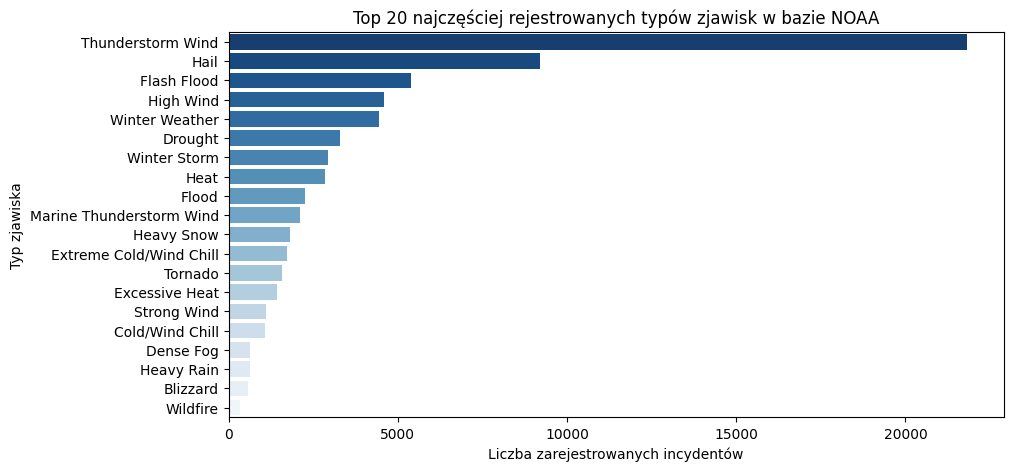

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Zliczam wystąpienia i biorę top 20 najczęstszych zdarzeń
sns.countplot(
    data=df_details,
    y='event_type',
    order=df_details['event_type'].value_counts().iloc[:20].index,
    palette='Blues_r'
)
plt.title('Top 20 najczęściej rejestrowanych typów zjawisk w bazie NOAA')
plt.xlabel('Liczba zarejestrowanych incydentów')
plt.ylabel('Typ zjawiska')
plt.show()

**Komentarz:**

Wykres przedstawia 20 najczęściej występujących typów zdarzeń.
W pierwszej trójce znajdują się silne wiatry, grad i powódź błyskawiczna.

### 4.2. Suma strat finansowych według typów zjawisk

Weryfikacja, czy najczęściej występujące zjawiska pogodowe są też tymi, które powodują największe straty finansowe w przypadku zniszczeń nieruchomości i upraw.

In [30]:
# Agreguję sumę strat dla nieruchomości i upraw dla każdego typu zjawiska
df_details['total_damage'] = df_details['damage_property'] + df_details['damage_crops']

/tmp/ipykernel_3186/2333735458.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


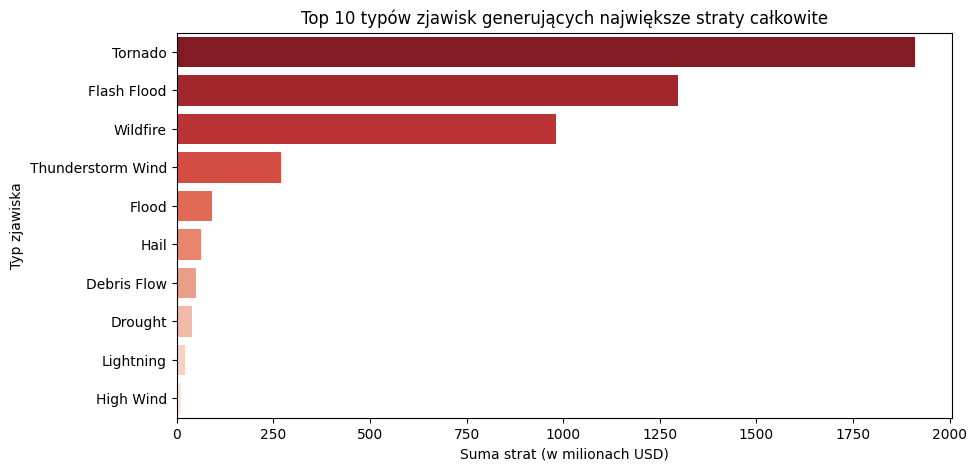

In [31]:
# 1. Agreguję dane i resetuję indeks
top_costs = df_details.groupby('event_type')['total_damage'].sum().reset_index()
top_costs = top_costs.sort_values(by='total_damage', ascending=False).head(10)

# Dzielę kolumnę przez 1 000 000, żeby mieć miliony
top_costs['total_damage_mln'] = top_costs['total_damage'] / 1_000_000

# 2. Rysuję wykres używając nowej, podzielonej kolumny
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_costs,
    x='total_damage_mln',  # używam wartości w milionach
    y='event_type',
    palette='Reds_r'
)

plt.title('Top 10 typów zjawisk generujących największe straty całkowite')
plt.xlabel('Suma strat (w milionach USD)')  # Informuję użytkownika o skali
plt.ylabel('Typ zjawiska')
plt.show()

In [32]:
top_costs

,event_type,total_damage,total_damage_mln
40,Tornado,1.909700e+09,1909.69950
12,Flash Flood,1.297936e+09,1297.93555
45,Wildfire,9.823471e+08,982.34711
39,Thunderstorm Wind,2.691166e+08,269.11658
13,Flood,9.240295e+07,92.40295
17,Hail,6.237250e+07,62.37250
5,Debris Flow,5.060120e+07,50.60120
7,Drought,3.950325e+07,39.50325
26,Lightning,2.261555e+07,22.61555
22,High Wind,1.221160e+07,12.21160


**Komentarz:**

Mimo, że tornada stanowią jedynie 2% wszystkich zjawisk, generują one największe straty finansowe wynoszące ponad 1,9 miliarda dolarów.
Tuż za tornadami znajdują się powodzie błyskawiczne i pożary obszarów naturalnych. Wiatry burzowe (Thunderstorm wind) znajdują się na 4-tym miejscu i generują straty o wysokości 269 mln dolarów.

Kluczowym wnioskiem jest, że najczęściej występujące zjawisko nie jest tym, które generuje największe straty finansowe.
Największe straty powodują rzadziej występujące, ale silniejsze i nieprzewidywalne tornada.

Z uwagi na to, że tornada są zjawiskami, które na podstawie tych danych powodują największe straty finansowe, zostają wybrane jako typ zjawiska, dla którego zostanie zbudowany model regresji liniowej.

## 4.3. Mapa rozmieszczenia tornad w kontynentalnej części USA

In [33]:
!pip install geodatasets
import geodatasets
import geopandas as gpd

In [34]:
tornado_event = df_details[df_details['event_type'] == 'Tornado']

/tmp/ipykernel_3186/397250155.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


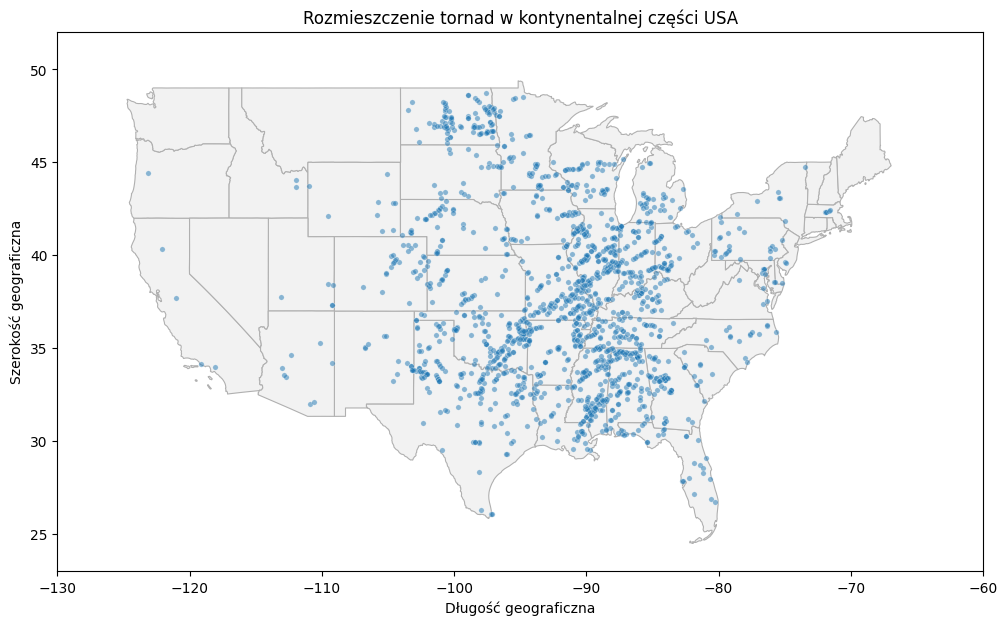

In [35]:

# 1. Pobieramy granice stanów USA bezpośrednio ze sprawdzonego źródła US Census Bureau
usa_url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
usa_states = gpd.read_file(usa_url)

# 2. Tworzymy wykres
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Rysujemy stany USA (jasnoszary obrys z szarymi granicami)
usa_states.plot(ax=ax, color='#f2f2f2', edgecolor='#b0b0b0', linewidth=0.8)

sns.scatterplot(
    data=tornado_event,
    x='begin_lon',
    y='begin_lat',
    palette='Set1',
    alpha=0.5,
    s=15,
    ax=ax
)

# Ustawiam sztywne granice widoku osi (Zoom na kontynentalne USA)
# Dane poza tymi granicami NIE są usuwane z DataFrame, po prostu wykraczają poza kadrującą ramkę.
ax.set_xlim(-130, -60)  # Długość geograficzna (od Wybrzeża Zachodniego do Wschodniego)
ax.set_ylim(23, 52)     # Szerokość geograficzna (od Florydy/Teksasu do granicy z Kanadą)

plt.title('Rozmieszczenie tornad w kontynentalnej części USA')
plt.xlabel('Długość geograficzna')
plt.ylabel('Szerokość geograficzna')
plt.show()


**Komentarz:**

Na podstawie mapy można wywnioskować, że najwięcej tornad występuje w środkowej i wschodniej części USA.

## 4.4. Wykres rozkładu strat finansowych generowanych przez tornada

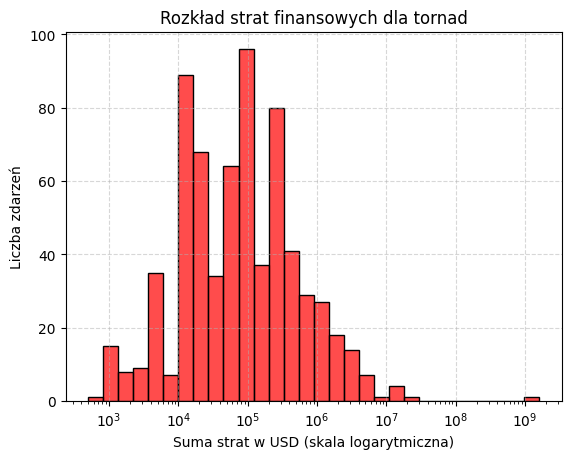

In [36]:
sns.histplot(
    data=tornado_event,
    x='total_damage',
    kde=True,
    color='red',
    bins=30,
    log_scale=True,
    alpha=0.7,
    edgecolor='black'
)

plt.title('Rozkład strat finansowych dla tornad')
plt.xlabel('Suma strat w USD (skala logarytmiczna)')
plt.ylabel('Liczba zdarzeń')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Komentarz:**

Zaprezentowany wykres w skali logarytmicznej ujawnia silną skośność prawostronną surowych danych. Zdecydowana większość tornad powoduje straty rzędu kilkunastu–kilkuset tysięcy dolarów, podczas gdy długi prawy ogon rozkładu sięga aż po wartości rzędu miliarda dolarów ($10^9$).

**Wnioski z EDA: **

Dotychczasowa analiza danych (EDA) ujawniła kluczowy wniosek dotyczący struktury strat materialnych:

Mimo że tornada stanowią znikomy odsetek wszystkich zarejestrowanych w bazie zdarzeń (zaledwie ok. 1 500 z ponad 70 000 wpisów), to odpowiadają one za największe zagregowane straty finansowe.

Z tego powodu to właśnie tornada zostały wybrane do dalszego modelowania predykcyjnego. Wizualizacja geograficzna ich rozmieszczenia na mapie kontynentalnej części USA potwierdza ich silną koncentrację regionalną oraz potencjał niszczycielski.

## 5. TESTOWANIE STATYSTYCZNE

Zanim przejdę do budowy modelu,  zweryfikuję statystycznie, czy siła fizyczna tornada (tor_f_scale_number) ma faktyczny, istotny wpływ na wysokość szkód.
Zastosuję nieparametryczny test Kruskala-Wallisa (odpowiednik testu ANOVA), ponieważ dane dotyczące strat mają rozkład silnie skośny.

Hipoteza ($H_0$): Średnie straty finansowe są takie same dla każdego stopnia skali Fujita (EF0–EF5).

Hipoteza alternatywna ($H_1$): Przynajmniej jeden stopień skali Fujita różni się istotnie pod względem wysokości wygenerowanych strat.

In [38]:
tornado_event.describe(include='all')

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source,month,hour,duration_minutes,tor_f_scale_number,total_damage
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1.591000e+03,1591,1591.000000,1591.0,1591,1591,1591,1591.000000,1591,1591,1591,1591,1591,1591.000000,1591.000000,1591.000000,1591.0,1.591000e+03,1591.000000,1591,0.0,0,0,0.0,1591,1591.000000,1591.000000,282,282,282.000000,282,1591.000000,1591,1591,1591.000000,1591,1591,1591.000000,1591.000000,1591.000000,1591.000000,1591,1591,1591,1591.000000,1591.000000,1591.000000,1338.000000,1.591000e+03
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,12,1,1,NaN,605,91,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,NaN,0,0,NaN,7,NaN,NaN,48,28,NaN,192,NaN,16,1386,NaN,16,1401,NaN,NaN,NaN,NaN,526,1552,1,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TEXAS,NaN,NaN,April,Tornado,C,NaN,WASHINGTON,MEG,NaN,CST-6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,NaN,NaN,JAN,MS,NaN,WASHINGTON,NaN,WSW,MERRITT RES,NaN,ENE,MERRITT RES,NaN,NaN,NaN,NaN,Isolated severe thunderstorms developed across...,An EF-2 tornado began along US Highway 49 nort...,CSV,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143,NaN,NaN,370,1591,1591,NaN,22,79,NaN,1206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1257,NaN,NaN,NaN,NaN,623,NaN,NaN,28,38,NaN,7,NaN,132,8,NaN,146,8,NaN,NaN,NaN,NaN,32,4,1591,NaN,NaN,NaN,NaN,NaN
mean,202504.961659,15.301697,1500.607165,202504.961659,15.305468,1502.153991,202377.214331,1.261320e+06,NaN,28.007542,2025.0,NaN,NaN,NaN,97.940289,NaN,NaN,2025-05-15 03:09:54.569453312,NaN,2025-05-15 03:16:13.991200512,0.155877,0.005657,0.040226,0.0,1.198194e+06,2120.050283,NaN,NaN,NaN,NaN,NaN,NaN,3.987203,243.283470,NaN,NaN,100.212766,NaN,3.661898,NaN,NaN,3.704852,NaN,NaN,37.598206,-91.846931,37.622268,-91.792875,NaN,NaN,NaN,4.961659,14.710874,6.323696,0.841555,1.200314e+06
min,202501.000000,1.000000,1.000000,202501.000000,1.000000,1.000000,197604.000000,1.222429e+06,NaN,1.000000,2025.0,NaN,NaN,NaN,1.000000,NaN,NaN,2025-01-03 17:18:00,NaN,2025-01-03 17:21:00,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,1.000000,NaN,NaN,1.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,26.070000,-123.104300,26.069600,-123.102700,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,202504.000000,7.000000,1242.000000,202504.000000,7.000000,1244.000000,200830.000000,1.247988e+06,NaN,17.000000,2025.0,NaN,NaN,NaN,37.000000,NaN,NaN,2025-04-02 16:02:30,NaN,2025-04-02 16:06:30,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.820000,50.000000,NaN,NaN,43.000000,NaN,1.380000,NaN,NaN,1.380000,NaN,NaN,33.938250,-96.769700,33.963200,-96.742100,NaN,NaN,NaN,4.000000,12.000000,2.000000,0.000000,0.000000e+00
50%,202505.000000,16.000000,1641.000000,202505.000000,16.000000,1644.000000,202012.000000,1.258709e+06,NaN,28.000000,2025.0,NaN,NaN,NaN,81.000000,NaN,NaN,2025-05-15 12:05:00,NaN,2025-05-15 12:14:00,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.390000,100.000000,NaN,NaN,83.000000,NaN,2.350000,NaN,NaN,2.420000,NaN,NaN,36.964400,-90.620000,37.010000,-90.550000,NaN,NaN,NaN,5.000000,16.000000,4.000000,1.000000,0.000000e+00
75%,202506.000000,20.000000,1931.000000,202506.000000,20.000000,1930.500000,203143.000000,1.274304e+06,NaN,40.000000,2025.0,NaN,NaN,NaN,130.000000,NaN,NaN,2025-06-16 18:01:00,NaN,2025-06-16 18:06:30,0.000000,0.0000

Przed przeprowadzeniem testu sprawdzam statystyki w tabeli, przede wszystkim czy w zmiennych objaśniających, które będę chciała wykorzystać są wartości Nan.

Okazuje się, że wartości Nan znajdują się w kolumnie z siłą tornada (tor_f_scale_number). Przed konwersją wartości w tej kolumnie na cyfry, kolumna ta zawierała np. wartości EFU (Unknown - tornada o nieznanej sile) lub Nan. Po konwersji EFU również zmieniło się na Nan.

Podejmuję decyzję o usunięciu wierszy z Nan w kolumnie 'tor_f_scale_number', gdyż w model będzie służył predykcji strat uzależnionych właśnie od tej siły. Zamiana tych Nan np. na 0 mogłaby zafałszować wyniki.

In [53]:
# Filtruję dane, zostawiając tylko wiersze ze znaną skalą Fujita
tornado_clean = tornado_event.dropna(subset=['tor_f_scale_number']).copy()

# Upewniam się, że skala jest typem całkowitoliczbowym (int)
tornado_clean['tor_f_scale_number'] = tornado_clean['tor_f_scale_number'].astype(int)

In [55]:
from scipy import stats

# 1. Tworzę grupy (pudełka) ze stratami dla poszczególnych stopni skali (EF0, EF1, EF2...)
groups = [group['total_damage'] for name, group in tornado_clean.groupby('tor_f_scale_number')]

# 2. Przekazuję zgrupowane dane do testu (gwiazdka * rozpakowuje naszą listę grup)
stat, p_value = stats.kruskal(*groups)

print(f"Statystyka testowa: {stat:.4f}")
print(f"p-value: {p_value}")

Statystyka testowa: 82.5631
p-value: 2.4397157094030747e-16


Interpretacja wyników testu Kruskala-Wallisa:

Wynik: P-value wynoszące ok. $2.44 \times 10^{-16}$ jest znacznie niższe od przyjętego poziomu istotności $\alpha = 0.05$.Decyzja: Mamy pełne podstawy do odrzucenia hipotezy zerowej ($H_0$) na rzecz hipotezy alternatywnej ($H_1$).Wniosek merytoryczny: Różnice w wysokości strat finansowych pomiędzy poszczególnymi stopniami skali Fujita są statystycznie wysoce istotne. Siła tornada bezpośrednio przekłada się na skalę zniszczeń, co w pełni uzasadnia włączenie zmiennej tor_f_scale_number do budowanego modelu regresji.

# 6. MODELOWANIE

In [61]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = tornado_clean[['tor_f_scale_number', 'tor_length', 'tor_width', 'month', 'hour', 'begin_lat', 'begin_lon', 'duration_minutes']]
y = tornado_clean['total_damage']

# 1. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. TRANSFORMACJA LOGARYTMICZNA ZMIENNEJ TARGET (y)
y_train_log = np.log1p(y_train)

# 3. Trening modelu na zlogarytmowanym y
model = LinearRegression()
model.fit(X_train, y_train_log)

# 4. Predykcja (wyniki będą w skali logarytmicznej)
y_pred_log = model.predict(X_test)

# 5. ODWRÓCENIE LOGARYTMU (powrót do surowych dolarów)
y_pred = np.expm1(y_pred_log)

# 6. Opcjonalne zabezpieczenie: zerowanie ewentualnych drobnych minusów
y_pred = np.clip(y_pred, a_min=0, a_max=None)

In [66]:
# 1. Model przewiduje wartości w skali logarytmicznej
y_pred_log = model.predict(X_test)

# 2. Odwracamy logarytm do pełnych kwot w USD
y_pred_usd = np.expm1(y_pred_log)

In [65]:
model.predict([[5, 3.0, 85.0, 5, 17, 43.7900, -83.1000, 10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6.62545929])

## 7. WNIOSKI

Wynikiem mini-projektu jest

Wniosek do projektu: "Stworzyłam model predykcji strat dedykowany dla tornad, wykorzystujący parametry geometrii i siły zjawiska".